## Projet : Analyse des ventes d’une chaîne de magasins (Retail Sales Analysis)
Objectif business :
Comprendre les performances de ventes, identifier les meilleurs produits/régions/clients, détecter les tendances et proposer des recommandations.

In [6]:
# 1 Collecte & Nettoyage des données

import pandas as pd
import numpy as np

df = pd.read_csv(
    r"C:\\Users\\jeora\\Downloads\\archive (9)\\Sample - Superstore.csv",
    encoding='latin-1'
    )

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
# Aperçu général

print(df.info())
print("\nValeurs manquantes par colonne :")

print(df.isnull().sum())

print("\nDoubles par colonne :")
print(df.duplicated().sum())

print("\nColonnes :")
print(df.columns.tolist())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [10]:
print("=== Noms des colonnes ===")
print(df.columns.tolist())

print("\n=== Aperçu des 5 premières lignes ===")
print(df.head())

print("\n=== Types de données ===")
print(df.dtypes)

=== Noms des colonnes ===
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Order_Year', 'Order_Month', 'Order_Quarter', 'Order_Day', 'Order_Month_Name', 'Delivery_Days', 'Profit_Margin']

=== Aperçu des 5 premières lignes ===
   Row ID        Order ID Order Date  Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
1       2  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
2       3  CA-2016-138688 2016-06-12 2016-06-16    Second Class    DV-13045   
3       4  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   
4       5  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ... Quantity  \
0      C

In [11]:
import pandas as pd
import numpy as np

# === 1. Vérification des colonnes importantes ===
required_cols = ['Order Date', 'Ship Date', 'Sales', 'Profit']
missing_cols = [col for col in required_cols if col not in df.columns]

if missing_cols:
    print("Colonnes manquantes :", missing_cols)
    print("Colonnes disponibles :", df.columns.tolist())
else:
    print("Toutes les colonnes importantes sont présentes.")

# === 2. Conversion des dates (plus robuste) ===
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')
df['Ship Date']  = pd.to_datetime(df['Ship Date'], errors='coerce')

# Vérifier s'il y a des dates non converties
print("Dates Order Date non converties :", df['Order Date'].isna().sum())
print("Dates Ship Date non converties  :", df['Ship Date'].isna().sum())

# === 3. Création des nouvelles colonnes ===
df['Order Year']       = df['Order Date'].dt.year
df['Order Month']      = df['Order Date'].dt.month
df['Order Quarter']    = df['Order Date'].dt.quarter
df['Order Day']        = df['Order Date'].dt.day_name()
df['Order Month Name'] = df['Order Date'].dt.month_name()

# Délai de livraison
df['Shipping Days'] = (df['Ship Date'] - df['Order Date']).dt.days

# Marge en pourcentage
df['Profit Margin'] = np.where(
    df['Sales'] != 0,
    (df['Profit'] / df['Sales']) * 100,
    0
)

# Arrondir
df['Sales']         = df['Sales'].round(2)
df['Profit']        = df['Profit'].round(2)
df['Discount']      = df['Discount'].round(2)
df['Profit Margin'] = df['Profit Margin'].round(2)

# === 4. Vérification ===
print("\n=== Nouvelles colonnes créées ===")
print(df[['Order Date', 'Order Year', 'Order Month', 'Shipping Days', 
          'Sales', 'Profit', 'Profit Margin']].head(10))

Toutes les colonnes importantes sont présentes.
Dates Order Date non converties : 0
Dates Ship Date non converties  : 0

=== Nouvelles colonnes créées ===
  Order Date  Order Year  Order Month  Shipping Days   Sales  Profit  \
0 2016-11-08        2016           11              3  261.96   41.91   
1 2016-11-08        2016           11              3  731.94  219.58   
2 2016-06-12        2016            6              4   14.62    6.87   
3 2015-10-11        2015           10              7  957.58 -383.03   
4 2015-10-11        2015           10              7   22.37    2.52   
5 2014-06-09        2014            6              5   48.86   14.17   
6 2014-06-09        2014            6              5    7.28    1.97   
7 2014-06-09        2014            6              5  907.15   90.72   
8 2014-06-09        2014            6              5   18.50    5.78   
9 2014-06-09        2014            6              5  114.90   34.47   

   Profit Margin  
0          16.00  
1          30.

In [12]:
# Sauvegarde en CSV propre (pour Power BI et SQL)
df.to_csv(r"C:\Users\jeora\Downloads\Superstore_Clean.csv", index=False)

print("Fichier nettoyé sauvegardé avec succès !")
print("Shape final :", df.shape)

Fichier nettoyé sauvegardé avec succès !
Shape final : (9994, 35)


## 2.Analyse SQL

In [13]:
import sqlite3
import pandas as pd

# Charger le fichier nettoyé
df_clean = pd.read_csv(r"C:\Users\jeora\Downloads\Superstore_Clean.csv")

# Créer / se connecter à la base SQLite
conn = sqlite3.connect(r"C:\Users\jeora\Downloads\superstore.db")

# Charger le DataFrame dans une table SQL
df_clean.to_sql('orders', conn, if_exists='replace', index=False)

print("Base SQLite créée avec succès !")
print("Nombre de lignes chargées :", len(df_clean))

Base SQLite créée avec succès !
Nombre de lignes chargées : 9994


In [14]:
# Voir les tables
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)
print(tables)

# Aperçu de la table
preview = pd.read_sql("SELECT * FROM orders LIMIT 5;", conn)
preview

     name
0  orders


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Order_Month_Name,Delivery_Days,Profit_Margin,Order Year,Order Month,Order Quarter,Order Day,Order Month Name,Shipping Days,Profit Margin
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,November,3,15.998626,2016,11,4,Tuesday,November,3,16.00
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,November,3,29.999727,2016,11,4,Tuesday,November,3,30.00
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,June,4,46.990424,2016,6,2,Sunday,June,4,46.99
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,October,7,-39.999791,2015,10,4,Sunday,October,7,-40.00
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,October,7,11.265087,2015,10,4,Sunday,October,7,11.27


In [16]:
# 1. Connexion (si ce n'est pas déjà fait)
conn = sqlite3.connect(r"C:\Users\jeora\Downloads\superstore.db")

# 2. Écrire la requête SQL
query = """
SELECT 
    "Product Name",
    Category,
    ROUND(SUM(Sales), 2) AS Total_Sales,
    ROUND(SUM(Profit), 2) AS Total_Profit,
    SUM(Quantity) AS Total_Quantity
FROM orders
GROUP BY "Product Name", Category
ORDER BY Total_Sales DESC
LIMIT 10;
"""

# 3. Exécuter la requête
result = pd.read_sql(query, conn)

# 4. Afficher le résultat
result

,Product Name,Category,Total_Sales,Total_Profit,Total_Quantity
0,Canon imageCLASS 2200 Advanced Copier,Technology,61599.83,25199.94,20
1,Fellowes PB500 Electric Punch Plastic Comb Bin...,Office Supplies,27453.38,7753.04,31
2,Cisco TelePresence System EX90 Videoconferenci...,Technology,22638.48,-1811.08,6
3,HON 5400 Series Task Chairs for Big and Tall,Furniture,21870.57,0.00,39
4,GBC DocuBind TL300 Electric Binding System,Office Supplies,19823.47,2233.50,37
5,GBC Ibimaster 500 Manual ProClick Binding System,Office Supplies,19024.50,760.98,48
6,Hewlett Packard LaserJet 3310 Copier,Technology,18839.68,6983.89,38
7,HP Designjet T520 Inkjet Large Format Printer ...,Technology,18374.89,4094.98,12
8,GBC DocuBind P400 Electric Binding System,Office Supplies,17965.07,-1878.17,27
9,High Speed Automatic Electric Letter Opener,Office Supplies,17030.31,-262.00,11


In [ ]:
# Performance par Région

# 1. Connexion (si ce n'est pas déjà fait)
conn = sqlite3.connect(r"C:\Users\jeora\Downloads\superstore.db")

# 2. Écrire la requête SQL
query = """
SELECT 
    Region,
    ROUND(SUM(Sales), 2) AS Total_Sales,
    ROUND(SUM(Profit), 2) AS Total_Profit,
    ROUND(AVG("Profit Margin"), 2) AS Avg_Margin,
    COUNT(DISTINCT "Order ID") AS Nb_Orders
FROM orders
GROUP BY Region
ORDER BY Total_Sales DESC;
"""

# 3. Exécuter la requête
result = pd.read_sql(query, conn)

# 4. Afficher le résultat
result

,Region,Total_Sales,Total_Profit,Avg_Margin,Nb_Orders
0,West,725457.76,108418.31,21.95,1611
1,East,678781.30,91522.50,16.72,1401
2,Central,501239.76,39706.24,-10.41,1175
3,South,391721.83,46749.49,16.35,822


In [18]:
# Évolution des ventes

# 1. Connexion (si ce n'est pas déjà fait)
conn = sqlite3.connect(r"C:\Users\jeora\Downloads\superstore.db")

# 2. Écrire la requête SQL
query = """
SELECT 
    "Order Year",
    "Order Month",
    "Order Month Name",
    ROUND(SUM(Sales), 2) AS Total_Sales,
    ROUND(SUM(Profit), 2) AS Total_Profit
FROM orders
GROUP BY "Order Year", "Order Month", "Order Month Name"
ORDER BY "Order Year", "Order Month";
"""

# 3. Exécuter la requête
result = pd.read_sql(query, conn)

# 4. Afficher le résultat
result



,Order Year,Order Month,Order Month Name,Total_Sales,Total_Profit
0,2014,1,January,14236.90,2450.17
1,2014,2,February,4519.92,862.30
2,2014,3,March,55691.02,498.70
3,2014,4,April,28295.35,3488.83
4,2014,5,May,23648.27,2738.72
5,2014,6,June,34595.12,4976.55
6,2014,7,July,33946.37,-841.47
7,2014,8,August,27909.47,5318.07
8,2014,9,September,81777.32,8328.07
9,2014,10,October,31453.37,3448.21


In [19]:
# Clients qui génèrent le plus de profit (RFM basique)

# 1. Connexion (si ce n'est pas déjà fait)
conn = sqlite3.connect(r"C:\Users\jeora\Downloads\superstore.db")

# 2. Écrire la requête SQL
query = """
SELECT 
    "Customer ID",
    "Customer Name",
    Segment,
    COUNT(DISTINCT "Order ID") AS Frequency,               -- Nombre de commandes
    ROUND(SUM(Sales), 2) AS Monetary,                      -- Chiffre d'affaires total
    ROUND(SUM(Profit), 2) AS Total_Profit,                 -- Profit total
    ROUND(AVG("Profit Margin"), 2) AS Avg_Margin,
    MAX("Order Date") AS Last_Order_Date                   -- Dernière commande (Recency)
FROM orders
GROUP BY "Customer ID", "Customer Name", Segment
ORDER BY Total_Profit DESC
LIMIT 20;
"""

# 3. Exécuter la requête
result = pd.read_sql(query, conn)

# 4. Afficher le résultat
result


,Customer ID,Customer Name,Segment,Frequency,Monetary,Total_Profit,Avg_Margin,Last_Order_Date
0,TC-20980,Tamara Chand,Corporate,5,19052.22,8981.32,21.29,2016-11-26
1,RB-19360,Raymond Buch,Consumer,6,15117.35,6976.09,20.96,2017-09-25
2,SC-20095,Sanjit Chand,Consumer,9,14142.34,5757.42,26.30,2017-01-15
3,HL-15040,Hunter Lopez,Consumer,6,12873.30,5622.43,31.41,2017-11-17
4,AB-10105,Adrian Barton,Consumer,10,14473.56,5444.81,-8.32,2017-11-19
5,TA-21385,Tom Ashbrook,Home Office,4,14595.62,4703.80,14.50,2017-10-22
6,CM-12385,Christopher Martinez,Consumer,4,8954.01,3899.90,17.90,2017-11-23
7,KD-16495,Keith Dawkins,Corporate,12,8181.24,3038.57,24.51,2017-09-09
8,AR-10540,Andy Reiter,Consumer,6,6608.45,2884.61,38.44,2017-12-24
9,DR-12940,Daniel Raglin,Home Office,8,8350.87,2869.07,3.91,2017-11-10


In [20]:
# Commandes avec perte (approximation des "retours" / mauvaises commandes)

# 1. Connexion (si ce n'est pas déjà fait)
conn = sqlite3.connect(r"C:\Users\jeora\Downloads\superstore.db")

# 2. Écrire la requête SQL
query = """
-- Vue d'ensemble des commandes déficitaires
SELECT 
    COUNT(DISTINCT "Order ID") AS Nb_Commandes_Perte,
    COUNT(DISTINCT "Order ID") * 100.0 / (SELECT COUNT(DISTINCT "Order ID") FROM orders) AS Pourcentage_Commandes_Perte,
    ROUND(SUM(Sales), 2) AS CA_des_Commandes_Perte,
    ROUND(SUM(Profit), 2) AS Perte_Totale
FROM orders
WHERE Profit < 0;
"""

# 3. Exécuter la requête
result = pd.read_sql(query, conn)

# 4. Afficher le résultat
result


,Nb_Commandes_Perte,Pourcentage_Commandes_Perte,CA_des_Commandes_Perte,Perte_Totale
0,1318,26.312637,468707.04,-156131.64


In [21]:
# Commandes avec perte (approximation des "retours" / mauvaises commandes)

# 1. Connexion (si ce n'est pas déjà fait)
conn = sqlite3.connect(r"C:\Users\jeora\Downloads\superstore.db")

# 2. Écrire la requête SQL
query = """
SELECT 
    Category,
    "Sub-Category",
    COUNT(DISTINCT "Order ID") AS Nb_Commandes_Perte,
    ROUND(SUM(Sales), 2) AS CA_Perte,
    ROUND(SUM(Profit), 2) AS Perte_Totale,
    ROUND(AVG(Discount), 2) AS Remise_Moyenne
FROM orders
WHERE Profit < 0
GROUP BY Category, "Sub-Category"
ORDER BY Perte_Totale ASC;   -- du plus négatif au moins négatif
"""

# 3. Exécuter la requête
result = pd.read_sql(query, conn)

# 4. Afficher le résultat
result


,Category,Sub-Category,Nb_Commandes_Perte,CA_Perte,Perte_Totale,Remise_Moyenne
0,Office Supplies,Binders,526,36140.61,-38510.57,0.74
1,Furniture,Tables,195,104978.54,-32412.21,0.37
2,Technology,Machines,41,72456.21,-30118.71,0.58
3,Furniture,Bookcases,107,48072.73,-12152.29,0.35
4,Furniture,Chairs,226,91988.48,-9880.92,0.26
5,Office Supplies,Appliances,65,3382.48,-8629.67,0.80
6,Technology,Phones,126,35797.85,-7530.65,0.34
7,Furniture,Furnishings,156,12845.81,-6490.88,0.53
8,Office Supplies,Storage,152,37869.05,-6426.30,0.20
9,Office Supplies,Supplies,33,14067.18,-3015.62,0.20


In [22]:
# 3. Analyse de saisonnalité)

# 1. Connexion (si ce n'est pas déjà fait)
conn = sqlite3.connect(r"C:\Users\jeora\Downloads\superstore.db")

# 2. Écrire la requête SQL
query = """
SELECT 
    "Order Month",
    "Order Month Name",
    ROUND(SUM(Sales), 2) AS Total_Sales,
    ROUND(SUM(Profit), 2) AS Total_Profit,
    COUNT(DISTINCT "Order ID") AS Nb_Orders,
    ROUND(AVG("Profit Margin"), 2) AS Avg_Margin
FROM orders
GROUP BY "Order Month", "Order Month Name"
ORDER BY "Order Month";
"""

# 3. Exécuter la requête
result = pd.read_sql(query, conn)

# 4. Afficher le résultat
result


,Order Month,Order Month Name,Total_Sales,Total_Profit,Nb_Orders,Avg_Margin
0,1,January,94924.87,9134.46,178,11.91
1,2,February,59751.26,10294.59,162,11.67
2,3,March,205005.48,28594.59,354,12.13
3,4,April,137762.13,11587.45,343,10.47
4,5,May,155028.82,22411.29,369,9.83
5,6,June,152718.64,21285.81,364,10.95
6,7,July,147238.07,13832.63,338,12.10
7,8,August,159043.98,21776.96,341,13.78
8,9,September,307649.90,36857.32,688,13.92
9,10,October,200322.97,31784.06,417,10.09


In [23]:
# 3. Analyse de saisonnalité)

# 1. Connexion (si ce n'est pas déjà fait)
conn = sqlite3.connect(r"C:\Users\jeora\Downloads\superstore.db")

# 2. Écrire la requête SQL
query = """
SELECT 
    "Order Year",
    "Order Month",
    "Order Month Name",
    ROUND(SUM(Sales), 2) AS Total_Sales,
    ROUND(SUM(Profit), 2) AS Total_Profit,
    COUNT(DISTINCT "Order ID") AS Nb_Orders
FROM orders
GROUP BY "Order Year", "Order Month", "Order Month Name"
ORDER BY "Order Year", "Order Month";
"""
# 3. Exécuter la requête
result = pd.read_sql(query, conn)

# 4. Afficher le résultat
result


,Order Year,Order Month,Order Month Name,Total_Sales,Total_Profit,Nb_Orders
0,2014,1,January,14236.90,2450.17,32
1,2014,2,February,4519.92,862.30,28
2,2014,3,March,55691.02,498.70,71
3,2014,4,April,28295.35,3488.83,66
4,2014,5,May,23648.27,2738.72,69
5,2014,6,June,34595.12,4976.55,66
6,2014,7,July,33946.37,-841.47,65
7,2014,8,August,27909.47,5318.07,72
8,2014,9,September,81777.32,8328.07,130
9,2014,10,October,31453.37,3448.21,78


In [24]:
# 3. Analyse de saisonnalité)

# 1. Connexion (si ce n'est pas déjà fait)
conn = sqlite3.connect(r"C:\Users\jeora\Downloads\superstore.db")

# 2. Écrire la requête SQL
query = """
SELECT 
    "Order Year",
    "Order Quarter",
    ROUND(SUM(Sales), 2) AS Total_Sales,
    ROUND(SUM(Profit), 2) AS Total_Profit,
    COUNT(DISTINCT "Order ID") AS Nb_Orders
FROM orders
GROUP BY "Order Year", "Order Quarter"
ORDER BY "Order Year", "Order Quarter";
"""
# 3. Exécuter la requête
result = pd.read_sql(query, conn)

# 4. Afficher le résultat
result


,Order Year,Order Quarter,Total_Sales,Total_Profit,Nb_Orders
0,2014,1,74447.84,3811.17,131
1,2014,2,86538.74,11204.10,201
2,2014,3,143633.16,12804.67,267
3,2014,4,179627.73,21723.92,370
4,2015,1,68851.74,9264.93,144
5,2015,2,89124.27,12190.90,214
6,2015,3,130259.48,16853.62,274
7,2015,4,182296.90,23308.99,406
8,2016,1,93237.19,11441.35,179
9,2016,2,136082.29,16390.26,294


## Analyse Python (EDA + Insights)

In [25]:
# 1. Imports et chargement

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Style des graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("viridis")

# Charger le fichier nettoyé
df = pd.read_csv(r"C:\Users\jeora\Downloads\Superstore_Clean.csv")

# Convertir les dates (au cas où)
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

print("Données chargées :", df.shape)
df.head()

Données chargées : (9994, 35)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Order_Month_Name,Delivery_Days,Profit_Margin,Order Year,Order Month,Order Quarter,Order Day,Order Month Name,Shipping Days,Profit Margin
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,November,3,15.998626,2016,11,4,Tuesday,November,3,16.00
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,November,3,29.999727,2016,11,4,Tuesday,November,3,30.00
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,June,4,46.990424,2016,6,2,Sunday,June,4,46.99
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,October,7,-39.999791,2015,10,4,Sunday,October,7,-40.00
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,October,7,11.265087,2015,10,4,Sunday,October,7,11.27


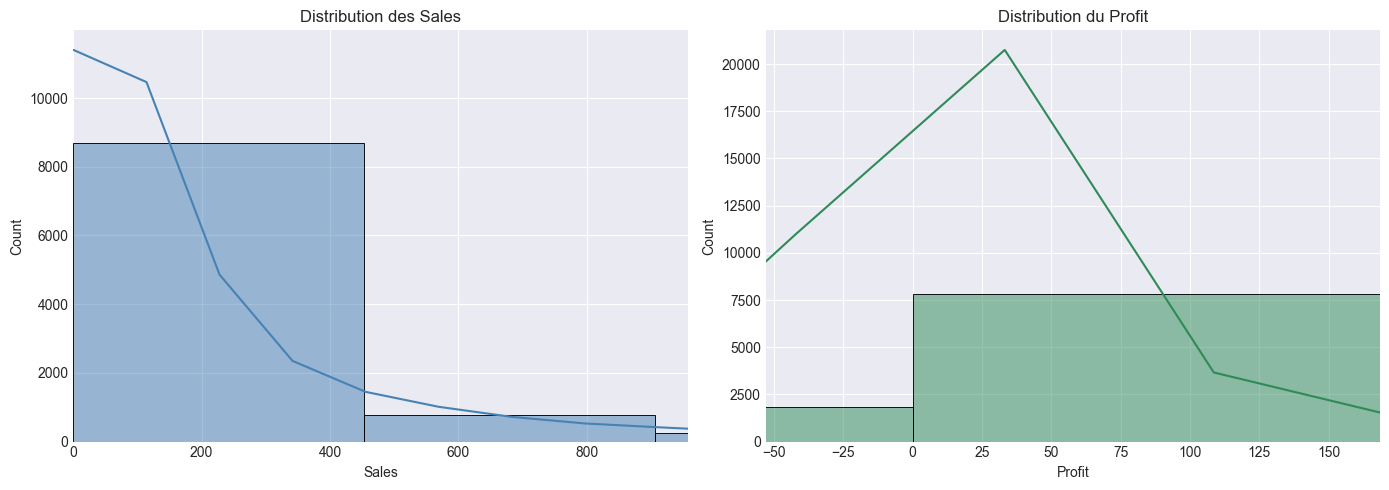

In [26]:
# 2. Distributions

# Distribution des Sales et Profit
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['Sales'], bins=50, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution des Sales')
axes[0].set_xlim(0, df['Sales'].quantile(0.95))  # on coupe les extrêmes pour mieux voir

sns.histplot(df['Profit'], bins=50, kde=True, ax=axes[1], color='seagreen')
axes[1].set_title('Distribution du Profit')
axes[1].set_xlim(df['Profit'].quantile(0.05), df['Profit'].quantile(0.95))

plt.tight_layout()
plt.show()


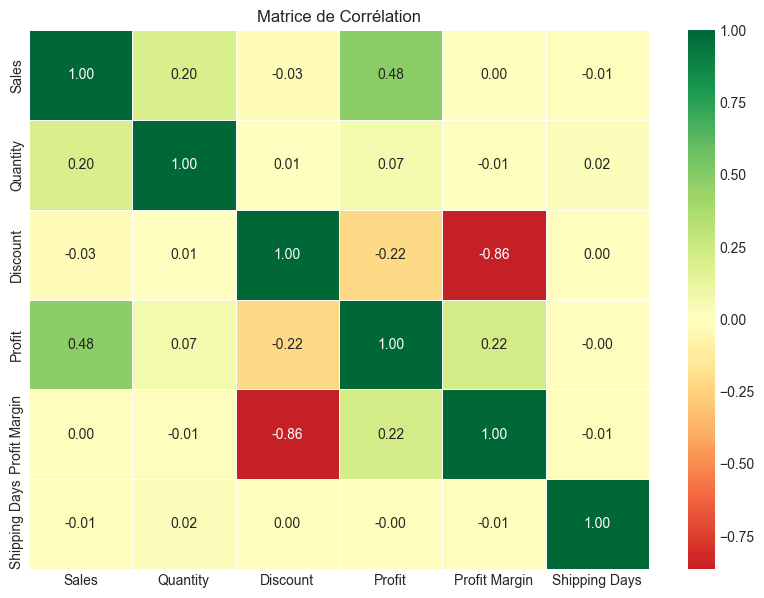

In [27]:
# 3 . Corrélations

# Matrice de corrélation
numeric_cols = ['Sales', 'Quantity', 'Discount', 'Profit', 'Profit Margin', 'Shipping Days']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', center=0, fmt='.2f', linewidths=0.5)
plt.title('Matrice de Corrélation')
plt.show()

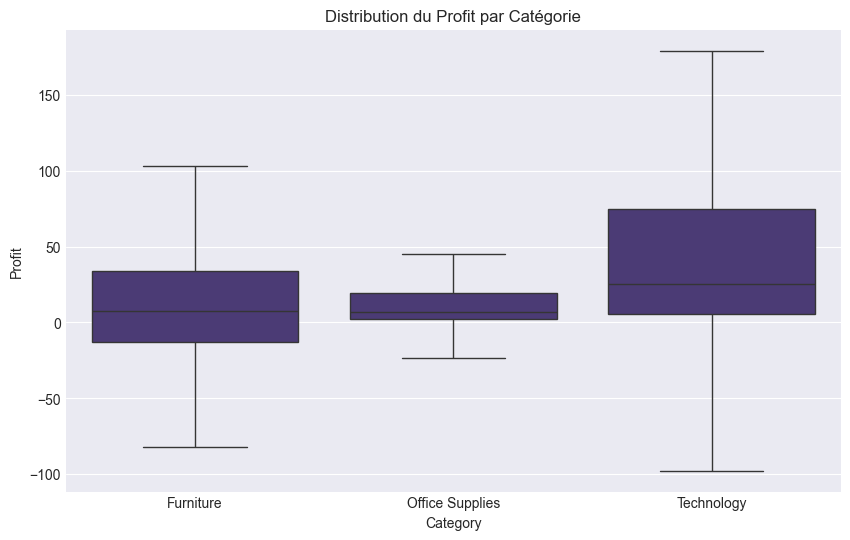

In [28]:
# 4 .Visualisations avancées
# Boxplot – Profit par Catégorie

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Category', y='Profit', showfliers=False)  # showfliers=False pour enlever les outliers extrêmes
plt.title('Distribution du Profit par Catégorie')
plt.ylabel('Profit')
plt.show()

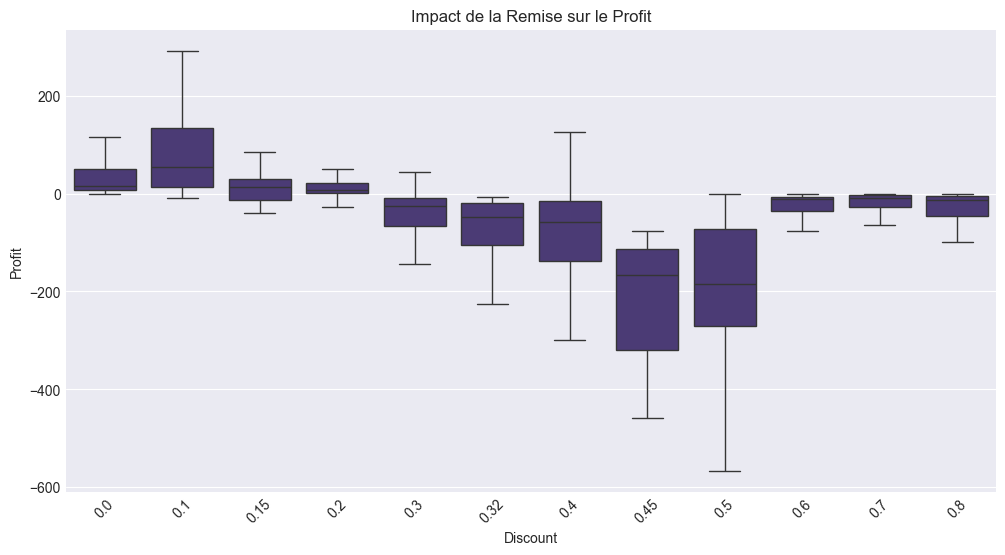

In [29]:
# Boxplot – Impact de la remise sur le profit

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Discount', y='Profit', showfliers=False)
plt.title('Impact de la Remise sur le Profit')
plt.xticks(rotation=45)
plt.show()

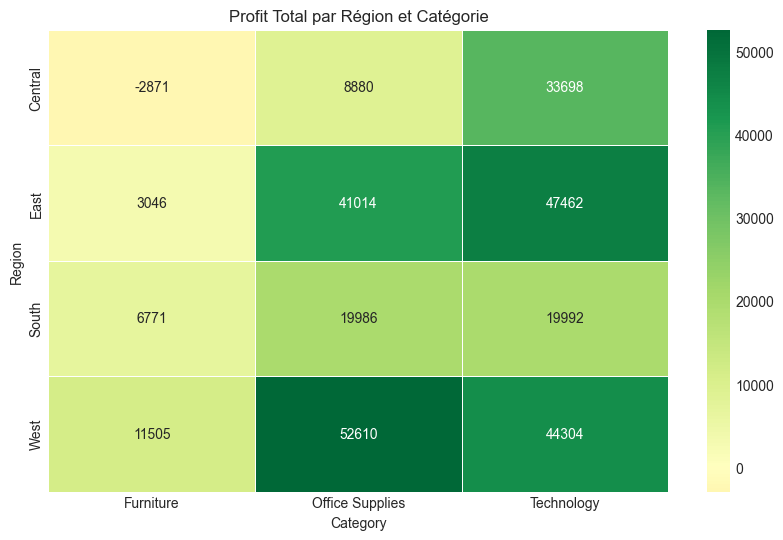

In [30]:
# Heatmap de performance (Région × Catégorie)

# Tableau croisé
pivot = df.pivot_table(
    values='Profit',
    index='Region',
    columns='Category',
    aggfunc='sum'
).round(0)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='RdYlGn', center=0, linewidths=0.5)
plt.title('Profit Total par Région et Catégorie')
plt.show()

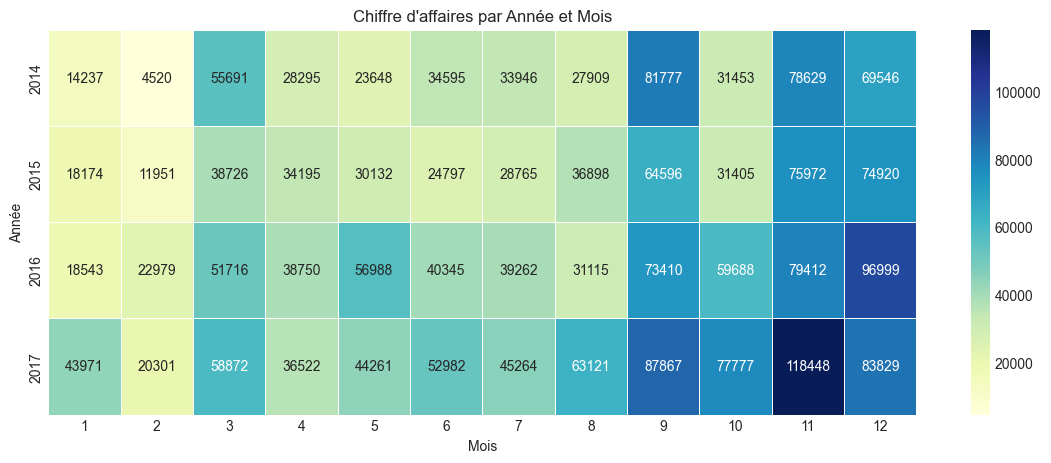

In [31]:
# Heatmap Saisonnalité (Année × Mois)

pivot_saison = df.pivot_table(
    values='Sales',
    index='Order Year',
    columns='Order Month',
    aggfunc='sum'
).round(0)

plt.figure(figsize=(14, 5))
sns.heatmap(pivot_saison, annot=True, fmt='.0f', cmap='YlGnBu', linewidths=0.5)
plt.title('Chiffre d\'affaires par Année et Mois')
plt.xlabel('Mois')
plt.ylabel('Année')
plt.show()


In [32]:
#  5. Analyse de cohortes simple (par année d’acquisition)

# On considère la première commande de chaque client comme sa cohorte
df['CohortYear'] = df.groupby('Customer ID')['Order Date'].transform('min').dt.year

# Résumé par cohorte
cohort_analysis = df.groupby('CohortYear').agg(
    Nb_Clients = ('Customer ID', 'nunique'),
    Total_Sales = ('Sales', 'sum'),
    Total_Profit = ('Profit', 'sum'),
    Avg_Order_Value = ('Sales', 'mean')
).round(2)

cohort_analysis['Sales_per_Customer'] = (cohort_analysis['Total_Sales'] / cohort_analysis['Nb_Clients']).round(2)
cohort_analysis

,Nb_Clients,Total_Sales,Total_Profit,Avg_Order_Value,Sales_per_Customer
CohortYear,,,,,
2014,595,1837324.35,219798.11,229.58,3087.94
2015,136,336654.61,46393.04,227.47,2475.40
2016,51,115709.88,18399.24,248.84,2268.82
2017,11,7511.81,1806.15,163.30,682.89


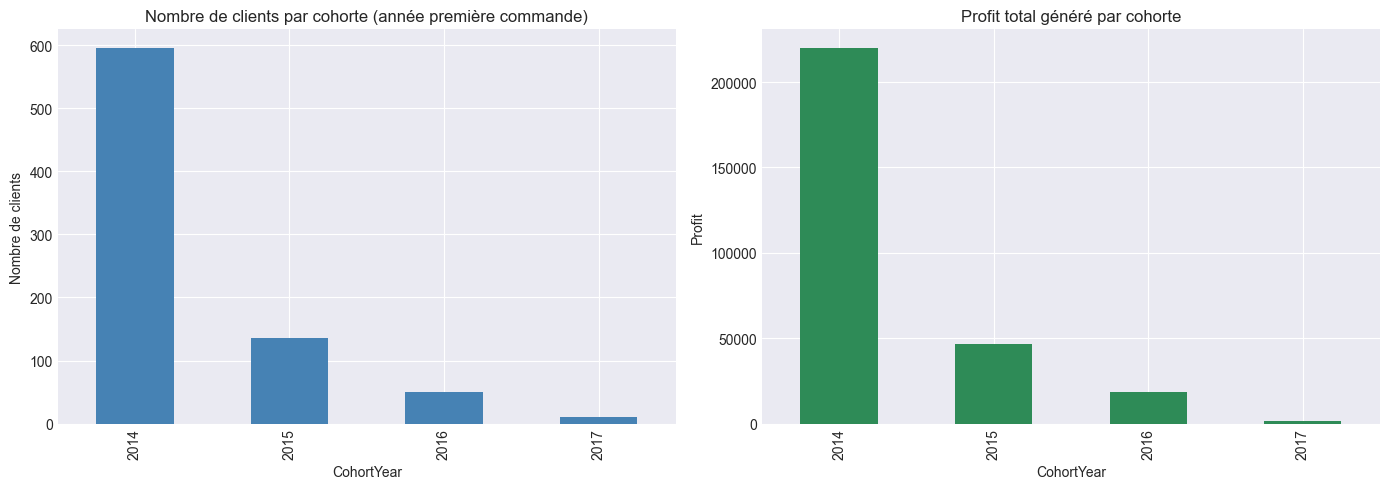

In [33]:
# 5. Visualisation de l'analyse de cohortes

# Visualisation
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

cohort_analysis['Nb_Clients'].plot(kind='bar', ax=ax[0], color='steelblue')
ax[0].set_title('Nombre de clients par cohorte (année première commande)')
ax[0].set_ylabel('Nombre de clients')

cohort_analysis['Total_Profit'].plot(kind='bar', ax=ax[1], color='seagreen')
ax[1].set_title('Profit total généré par cohorte')
ax[1].set_ylabel('Profit')

plt.tight_layout()
plt.show()

In [34]:
#  6. Insights rapides automatiques

print("=== INSIGHTS RAPIDES ===")
print(f"Chiffre d'affaires total     : {df['Sales'].sum():,.0f} $")
print(f"Profit total                 : {df['Profit'].sum():,.0f} $")
print(f"Marge moyenne                : {df['Profit Margin'].mean():.1f} %")
print(f"% de commandes déficitaires  : {(df['Profit'] < 0).mean()*100:.1f} %")
print(f"Remise moyenne               : {df['Discount'].mean()*100:.1f} %")
print(f"Meilleure région (Profit)    : {df.groupby('Region')['Profit'].sum().idxmax()}")
print(f"Meilleure catégorie (Profit) : {df.groupby('Category')['Profit'].sum().idxmax()}")

=== INSIGHTS RAPIDES ===
Chiffre d'affaires total     : 2,297,201 $
Profit total                 : 286,397 $
Marge moyenne                : 12.0 %
% de commandes déficitaires  : 18.7 %
Remise moyenne               : 15.6 %
Meilleure région (Profit)    : West
Meilleure catégorie (Profit) : Technology


In [35]:
# Exporter le fichier final enrichi
df.to_csv(r"C:\Users\jeora\Downloads\Superstore_Final_for_PowerBI.csv", index=False)
print("Fichier exporté pour Power BI avec succès !")

Fichier exporté pour Power BI avec succès !
